### Human narrative statics

In [10]:
from pathlib import Path
import re
import pandas as pd
import spacy


# -----------------------------
# 1. Load spaCy model
# -----------------------------
# Install first if needed:
# pip install spacy pandas
# python -m spacy download en_core_web_sm

nlp = spacy.load("en_core_web_sm")


# -----------------------------
# 2. Helper: clean text
# -----------------------------
def clean_text(text: str) -> str:
    """
    Basic cleaning for story text.
    """
    text = text.replace("\ufeff", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


# -----------------------------
# 3. Event extraction heuristic
# -----------------------------
def count_events(text: str) -> int:
    """
    Approximate number of narrative events in a story.

    Heuristic:
    - Count main verbs and predicate-like structures
    - Ignore auxiliaries and very weak reporting/light verbs when possible
    - Keep verbs that are likely to represent actions or state changes

    This is not a perfect narratological event parser,
    but it is a solid baseline for raw-text corpus statistics.
    """
    doc = nlp(text)

    light_verbs = {
        "be", "have", "do",
        "say", "tell", "ask",
        "seem", "become"
    }

    event_count = 0

    for token in doc:
        # Count lexical verbs but skip auxiliaries
        if token.pos_ == "VERB" and token.dep_ != "aux":
            lemma = token.lemma_.lower()

            # keep some reporting verbs if you want dialogue events counted;
            # here we exclude very common light/reporting verbs for cleaner stats
            if lemma not in light_verbs:
                event_count += 1

        # Optional: count important adjectives used as predicates
        # Example: "the king was furious" -> emotional state change
        elif token.pos_ == "ADJ" and token.dep_ == "acomp":
            event_count += 1

    return event_count


# -----------------------------
# 4. Read stories from folders
# -----------------------------
def load_human_stories_from_folders(root_dir: str) -> pd.DataFrame:
    """
    Reads all .txt stories from subfolders under root_dir.

    Assumes:
    - each subfolder name = culture
    - each .txt file inside = one story

    Returns a dataframe with:
    - culture
    - story_id
    - filepath
    - text
    """
    root = Path(root_dir)
    rows = []

    for culture_dir in root.iterdir():
        if not culture_dir.is_dir():
            continue

        culture = culture_dir.name

        for txt_file in culture_dir.glob("*.txt"):
            try:
                text = txt_file.read_text(encoding="utf-8")
            except UnicodeDecodeError:
                text = txt_file.read_text(encoding="latin-1")

            rows.append({
                "culture": culture,
                "story_id": txt_file.stem,
                "filepath": str(txt_file),
                "text": clean_text(text)
            })

    return pd.DataFrame(rows)


# -----------------------------
# 5. Build per-story statistics
# -----------------------------
def build_story_event_dataframe(root_dir: str) -> pd.DataFrame:
    """
    Loads stories and computes event counts per story.
    """
    df = load_human_stories_from_folders(root_dir)

    if df.empty:
        raise ValueError(f"No .txt files found under: {root_dir}")

    df["num_events"] = df["text"].apply(count_events)
    df["num_words"] = df["text"].apply(lambda x: len(x.split()))
    df["num_sentences"] = df["text"].apply(lambda x: len(list(nlp(x).sents)))

    return df


# -----------------------------
# 6. Aggregate per culture
# -----------------------------
def culture_summary_table(story_df: pd.DataFrame) -> pd.DataFrame:
    """
    Produces the final table:
    - Number of Stories
    - Avg. Events per Story
    per culture
    """
    summary = (
        story_df.groupby("culture")
        .agg(
            Number_of_Stories=("story_id", "nunique"),
            Avg_Events_per_Story=("num_events", "mean"),
            Avg_Words_per_Story=("num_words", "mean"),
            Avg_Sentences_per_Story=("num_sentences", "mean"),
        )
        .reset_index()
    )

    summary["Avg_Events_per_Story"] = summary["Avg_Events_per_Story"].round(2)
    summary["Avg_Words_per_Story"] = summary["Avg_Words_per_Story"].round(2)
    summary["Avg_Sentences_per_Story"] = summary["Avg_Sentences_per_Story"].round(2)

    return summary.sort_values("culture").reset_index(drop=True)


# -----------------------------
# 7. Main run
# -----------------------------
if __name__ == "__main__":
    ROOT_DIR = "data/human"   # change this to your folder path

    story_df = build_story_event_dataframe(ROOT_DIR)
    summary_df = culture_summary_table(story_df)

    print("\n=== Per-story data ===")
    print(story_df[["culture", "story_id", "num_events", "num_words", "num_sentences"]])

    print("\n=== Culture summary table ===")
    print(summary_df)

    # Save outputs
    story_df.to_csv("./report/human_story_event_counts.csv", index=False)
    summary_df.to_csv("./report/human_culture_summary.csv", index=False)

    print("\nSaved:")
    print("- human_story_event_counts.csv")
    print("- human_culture_summary.csv")


=== Per-story data ===
            culture story_id  num_events  num_words  num_sentences
0            german      g01         385       2530             79
1            german      g02         430       2932            138
2            german      g03         344       2341            101
3            german      g04         155       1194             41
4            german      g05         144       1139             47
5            german      g06         230       1605             52
6            german      g07         251       2120            118
7            german      g08         237       1585             61
8            german      g09         332       2340             76
9            german      g10         399       2414             96
10  native american      n01          52        348             21
11  native american      n02         101        537             31
12  native american      n03         130        815             78
13  native american      n04         1

### graph stats per story

In [1]:
from pathlib import Path
import pandas as pd
import networkx as nx
import json
from networkx.readwrite import json_graph


def infer_culture_from_story_id(story_id: str) -> str:
    """
    Infer culture from story folder name:
    g01 -> German
    p01 -> Persian
    n01 -> Native American
    """
    story_id = story_id.lower()

    if story_id.startswith("g"):
        return "German"
    elif story_id.startswith("p"):
        return "Persian"
    elif story_id.startswith("n"):
        return "Native American"
    else:
        return "Unknown"


def load_graph_from_json(graph_path: Path):
    """
    Load a graph from graph.json.
    Assumes NetworkX node-link JSON format.
    """
    with open(graph_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    return json_graph.node_link_graph(data)


def build_graph_stats_dataframe(root_dir="output/human_graphs"):
    """
    Reads graph.json from each story folder and returns per-story stats.
    Expected structure:
        output/human_graphs/g01/graph.json
        output/human_graphs/p01/graph.json
        output/human_graphs/n01/graph.json
    """
    root = Path(root_dir)
    rows = []

    for story_dir in root.iterdir():
        if not story_dir.is_dir():
            continue

        story_id = story_dir.name
        graph_file = story_dir / "graph.json"

        if not graph_file.exists():
            print(f"Skipping {story_id}: graph.json not found")
            continue

        try:
            G = load_graph_from_json(graph_file)
            culture = infer_culture_from_story_id(story_id)

            rows.append({
                "story_id": story_id,
                "culture": culture,
                "num_nodes": G.number_of_nodes(),
                "num_edges": G.number_of_edges(),
                "graph_path": str(graph_file)
            })

        except Exception as e:
            print(f"Skipping {story_id}: {e}")

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No valid graph.json files found in {root_dir}")

    return df


def create_culture_summary(graph_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create the final table:
    Culture | Avg. Nodes | Avg. Edges
    """
    summary = (
        graph_df.groupby("culture")
        .agg(
            Avg_Nodes=("num_nodes", "mean"),
            Avg_Edges=("num_edges", "mean")
        )
        .reset_index()
    )

    summary["Avg_Nodes"] = summary["Avg_Nodes"].round(2)
    summary["Avg_Edges"] = summary["Avg_Edges"].round(2)

    culture_order = ["Persian", "German", "Native American"]
    summary["culture"] = pd.Categorical(
        summary["culture"],
        categories=culture_order,
        ordered=True
    )

    summary = summary.sort_values("culture").reset_index(drop=True)

    summary = summary.rename(columns={
        "culture": "Culture",
        "Avg_Nodes": "Avg. Nodes",
        "Avg_Edges": "Avg. Edges"
    })

    return summary


if __name__ == "__main__":
    ROOT_DIR = "./outputs/human_graphs"

    graph_df = build_graph_stats_dataframe(ROOT_DIR)
    summary_df = create_culture_summary(graph_df)

    print("\n=== Per-story graph stats ===")
    print(graph_df[["story_id", "culture", "num_nodes", "num_edges"]])

    print("\n=== Final summary table ===")
    print(summary_df)

    graph_df.to_csv("./report/human_graph_stats_per_story.csv", index=False)
    summary_df.to_csv("./report/human_graph_summary_by_culture.csv", index=False)

    print("\nSaved files:")
    print("- human_graph_stats_per_story.csv")
    print("- human_graph_summary_by_culture.csv")


=== Per-story graph stats ===
   story_id          culture  num_nodes  num_edges
0       g01           German         76         75
1       g02           German        132        131
2       g03           German        100         99
3       g04           German         38         37
4       g05           German         43         42
5       g06           German         52         51
6       g07           German        117        116
7       g08           German         60         59
8       g09           German         75         74
9       g10           German         95         94
10      n01  Native American         20         19
11      n02  Native American         30         29
12      n03  Native American         78         77
13      n04  Native American         67         66
14      n05  Native American        119        118
15      n06  Native American         86         85
16      n07  Native American         84         83
17      n08  Native American         59         58


### visual example of the narrative graph (human)

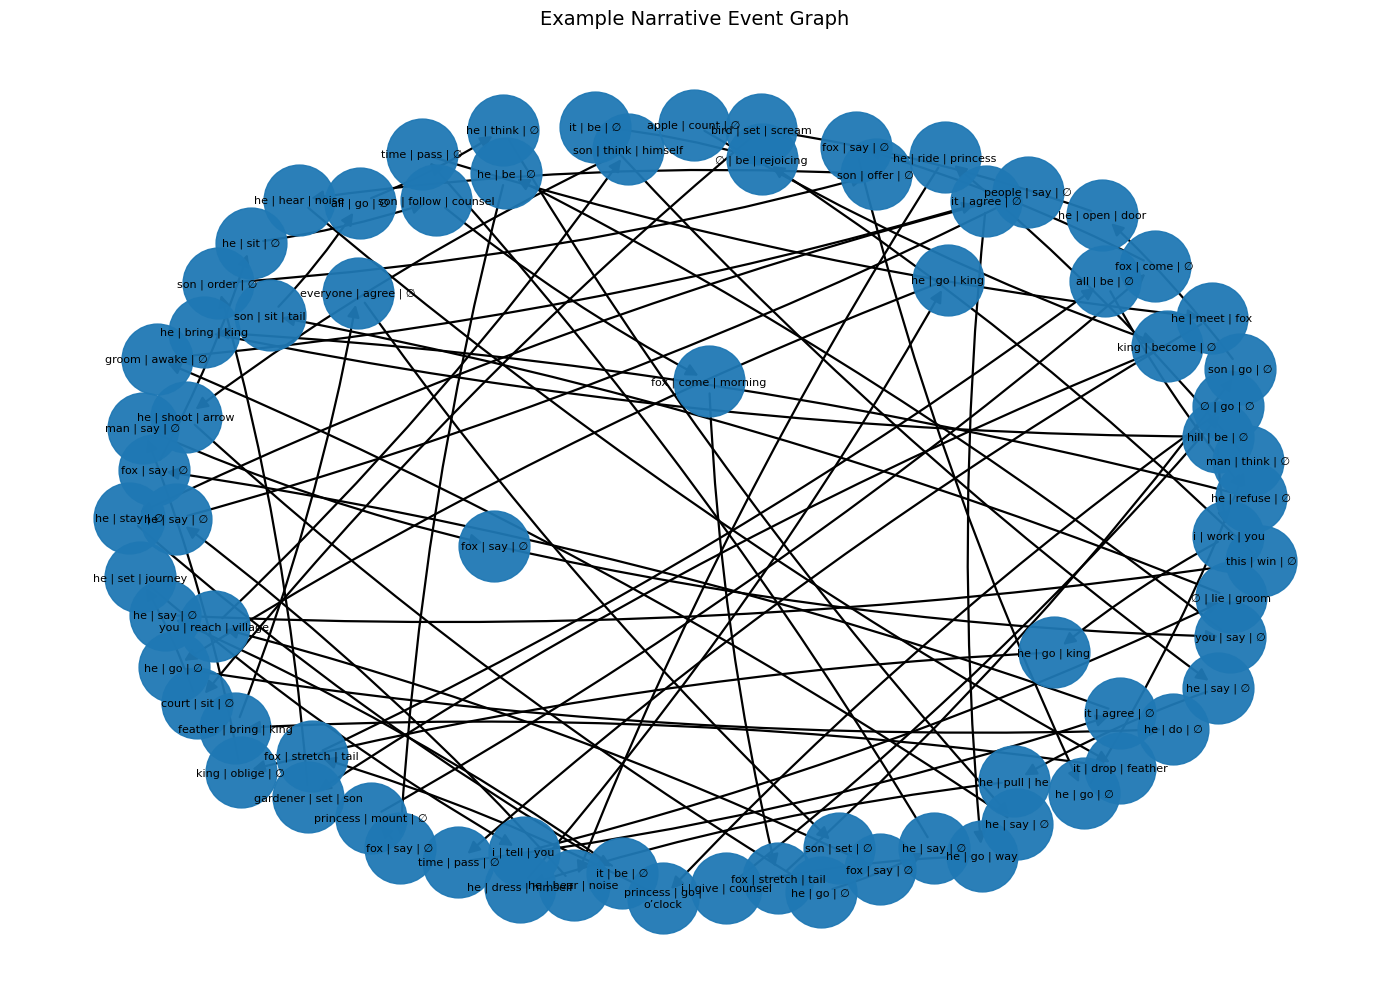

Saved figure to: ./report/event_graph_figure.png


In [22]:
from pathlib import Path
import json
import textwrap

import matplotlib.pyplot as plt
import networkx as nx
from networkx.readwrite import json_graph


# -------------------------------------------------
# Config
# -------------------------------------------------
story_idn= "g01"
STORY_DIR = Path("outputs/human_graphs/",story_idn)   # change to p01, n01, etc.
GRAPH_FILE = STORY_DIR / "graph.json"
EVENTS_FILE = STORY_DIR / "events.json"

OUTPUT_FILE = "./report/event_graph_figure.png"

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def load_graph(graph_path: Path) -> nx.DiGraph:
    with open(graph_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    G = json_graph.node_link_graph(data)

    # Force directed graph if needed
    if not isinstance(G, nx.DiGraph):
        G = nx.DiGraph(G)

    return G


def load_events(events_path: Path):
    if not events_path.exists():
        return None
    with open(events_path, "r", encoding="utf-8") as f:
        return json.load(f)


def make_svo_label(event_dict: dict) -> str:
    """
    Build a readable subject-verb-object label from an event dict.
    Adjust keys here if your event format differs.
    """
    subject = str(event_dict.get("subject", "")).strip()
    verb = str(event_dict.get("verb", "")).strip()
    obj = str(event_dict.get("object", "")).strip()

    parts = [p for p in [subject, verb, obj] if p]
    label = " | ".join(parts) if parts else str(event_dict.get("text", ""))

    return label if label else "event"


def build_node_labels(G: nx.Graph, events_data=None):
    """
    Priority:
    1. node['label']
    2. node['event'], node['text']
    3. events.json lookup
    4. fallback to node id
    """
    labels = {}

    # Build optional lookup from events.json
    events_lookup = {}
    if events_data is not None:
        if isinstance(events_data, list):
            for i, ev in enumerate(events_data):
                events_lookup[str(i)] = make_svo_label(ev) if isinstance(ev, dict) else str(ev)
                if isinstance(ev, dict):
                    for k in ["id", "event_id", "node_id"]:
                        if k in ev:
                            events_lookup[str(ev[k])] = make_svo_label(ev)
        elif isinstance(events_data, dict):
            for k, ev in events_data.items():
                events_lookup[str(k)] = make_svo_label(ev) if isinstance(ev, dict) else str(ev)

    for node, attrs in G.nodes(data=True):
        label = None

        if "label" in attrs and attrs["label"]:
            label = str(attrs["label"])
        elif "event" in attrs and attrs["event"]:
            if isinstance(attrs["event"], dict):
                label = make_svo_label(attrs["event"])
            else:
                label = str(attrs["event"])
        elif "text" in attrs and attrs["text"]:
            label = str(attrs["text"])
        else:
            node_key = str(node)
            if node_key in events_lookup:
                label = events_lookup[node_key]

        if not label:
            label = str(node)

        labels[node] = textwrap.fill(label, width=22)

    return labels


def hierarchical_layout(G: nx.DiGraph):
    """
    Try graphviz hierarchical layout first.
    Fall back to spring layout.
    """
    try:
        from networkx.drawing.nx_pydot import graphviz_layout
        return graphviz_layout(G, prog="dot")
    except Exception:
        return nx.spring_layout(G, seed=42, k=1.8)


# -------------------------------------------------
# Main plotting
# -------------------------------------------------
def plot_event_graph(story_dir: Path, output_file: Path):
    graph_file = story_dir / "graph.json"
    events_file = story_dir / "events.json"

    G = load_graph(graph_file)
    events_data = load_events(events_file)
    labels = build_node_labels(G, events_data)

    pos = hierarchical_layout(G)

    plt.figure(figsize=(14, 10))
    ax = plt.gca()

    nx.draw_networkx_nodes(
        G, pos,
        node_size=2600,
        alpha=0.95
    )

    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        width=1.6,
        connectionstyle="arc3,rad=0.05"
    )

    nx.draw_networkx_labels(
        G, pos,
        labels=labels,
        font_size=8
    )

    plt.title("Example Narrative Event Graph", fontsize=14, pad=14)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure to: {output_file}")


if __name__ == "__main__":
    plot_event_graph(STORY_DIR, OUTPUT_FILE)
    

### human graphs similarity graph

d:\University of Milan\Quarter1- 20252026\Natural Language Process\P12\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 30 stories with usable event graphs.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 966.39it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved pairwise scores to: report\cross_cultural_pairwise_scores.csv
Saved table CSV to: report\cross_cultural_similarity_table.csv
Saved table LaTeX to: report\cross_cultural_similarity_table.tex

Average narrative similarity across cultures:

               comparison  Average Similarity
 German – Native American              0.5999
         German – Persian              0.5862
Native American – Persian              0.5584


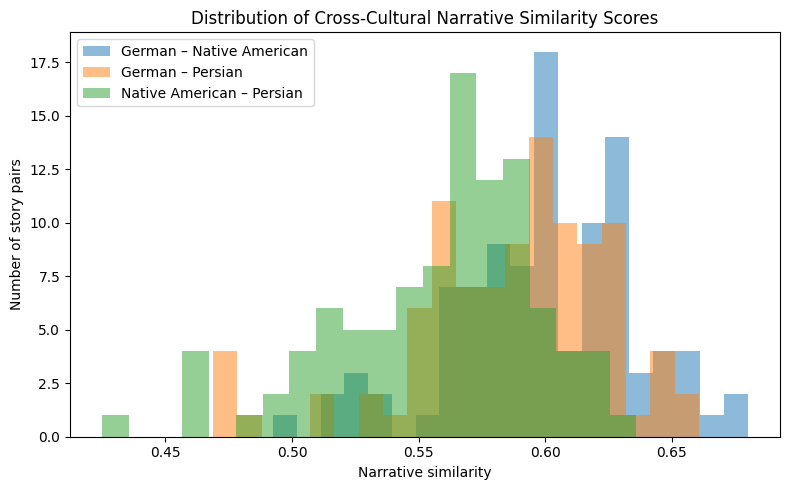

Saved figure to: report\cross_cultural_similarity_distribution.png


In [1]:
from pathlib import Path
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# Paths
# =========================
META_PATH = Path("data/metadata.csv")
EVENTS_ROOT = Path("outputs/human_graphs")
REPORT_DIR = Path("report")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PAIRWISE_OUT = REPORT_DIR / "cross_cultural_pairwise_scores.csv"
TABLE_OUT = REPORT_DIR / "cross_cultural_similarity_table.csv"
TABLE_LATEX_OUT = REPORT_DIR / "cross_cultural_similarity_table.tex"
FIG_OUT = REPORT_DIR / "cross_cultural_similarity_distribution.png"

# =========================
# Config
# =========================
MODEL_NAME = "all-MiniLM-L6-v2"

# =========================
# Helpers
# =========================
def normalize_culture_name(c: str) -> str:
    c = str(c).strip().lower().replace("_", " ")
    return c

def pretty_pair_name(c1: str, c2: str) -> str:
    names = sorted([c1.title(), c2.title()])
    return f"{names[0]} – {names[1]}"

def load_event_labels(story_id: str):
    path = EVENTS_ROOT / story_id / "events.json"
    if not path.exists():
        return []
    data = json.loads(path.read_text(encoding="utf-8"))
    return [x["label"] for x in data if "label" in x and str(x["label"]).strip()]

def story_similarity(labels_a, labels_b, model):
    """
    Symmetric event-sequence similarity using embeddings:
    - embed event labels
    - for each event in A, find best match in B
    - for each event in B, find best match in A
    - return average of both directions
    """
    if not labels_a or not labels_b:
        return np.nan

    emb_a = model.encode(labels_a, normalize_embeddings=True)
    emb_b = model.encode(labels_b, normalize_embeddings=True)

    sim = cosine_similarity(emb_a, emb_b)

    a_to_b = sim.max(axis=1).mean()
    b_to_a = sim.max(axis=0).mean()

    return float((a_to_b + b_to_a) / 2.0)

# =========================
# Load metadata
# =========================
meta = pd.read_csv(META_PATH)
required_cols = {"story_id", "culture"}
missing = required_cols - set(meta.columns)
if missing:
    raise ValueError(f"metadata.csv is missing columns: {missing}")

meta["culture"] = meta["culture"].apply(normalize_culture_name)

# load event labels
story_events = {}
usable_rows = []

for _, row in meta.iterrows():
    story_id = str(row["story_id"])
    culture = row["culture"]
    labels = load_event_labels(story_id)
    if labels:
        story_events[story_id] = labels
        usable_rows.append({"story_id": story_id, "culture": culture})

stories_df = pd.DataFrame(usable_rows)
if len(stories_df) < 2:
    raise ValueError("Not enough stories with extracted events.")

print(f"Loaded {len(stories_df)} stories with usable event graphs.")

# =========================
# Pairwise similarities
# =========================
model = SentenceTransformer(MODEL_NAME)

rows = []
story_rows = stories_df.to_dict("records")

for a, b in itertools.combinations(story_rows, 2):
    sid_a, sid_b = a["story_id"], b["story_id"]
    culture_a, culture_b = a["culture"], b["culture"]

    # cross-cultural only
    if culture_a == culture_b:
        continue

    score = story_similarity(story_events[sid_a], story_events[sid_b], model)
    pair_name = pretty_pair_name(culture_a, culture_b)

    rows.append({
        "story_id_1": sid_a,
        "culture_1": culture_a,
        "story_id_2": sid_b,
        "culture_2": culture_b,
        "comparison": pair_name,
        "similarity": score,
    })

pairwise_df = pd.DataFrame(rows)
pairwise_df.to_csv(PAIRWISE_OUT, index=False)

print(f"Saved pairwise scores to: {PAIRWISE_OUT}")

# =========================
# Average table
# =========================
table_df = (
    pairwise_df.groupby("comparison", as_index=False)["similarity"]
    .mean()
    .rename(columns={"similarity": "Average Similarity"})
    .sort_values("comparison")
)

table_df["Average Similarity"] = table_df["Average Similarity"].round(4)
table_df.to_csv(TABLE_OUT, index=False)

# latex table
latex_table = table_df.to_latex(index=False, float_format="%.4f")
TABLE_LATEX_OUT.write_text(latex_table, encoding="utf-8")

print(f"Saved table CSV to: {TABLE_OUT}")
print(f"Saved table LaTeX to: {TABLE_LATEX_OUT}")
print("\nAverage narrative similarity across cultures:\n")
print(table_df.to_string(index=False))

# =========================
# Figure: distribution
# =========================
plt.figure(figsize=(8, 5))
for comp, group in pairwise_df.groupby("comparison"):
    plt.hist(
        group["similarity"].dropna(),
        bins=20,
        alpha=0.5,
        label=comp
    )

plt.title("Distribution of Cross-Cultural Narrative Similarity Scores")
plt.xlabel("Narrative similarity")
plt.ylabel("Number of story pairs")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_OUT, dpi=300)
plt.show()

print(f"Saved figure to: {FIG_OUT}")

### human - same culture- cross culture similarity

d:\University of Milan\Quarter1- 20252026\Natural Language Process\P12\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3005.67it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved pairwise human–LLM scores to: report\human_llm_similarity_scores.csv
Saved summary table to: report\human_llm_similarity_table.csv
Saved LaTeX table to: report\human_llm_similarity_table.tex

Human–LLM similarity summary:

        culture     condition  Human–LLM Similarity
         German Cross Culture                0.6436
Native American Cross Culture                0.6308
        Persian Cross Culture                0.6055
         German  Same Culture                0.7591
Native American  Same Culture                0.7448
        Persian  Same Culture                0.7336


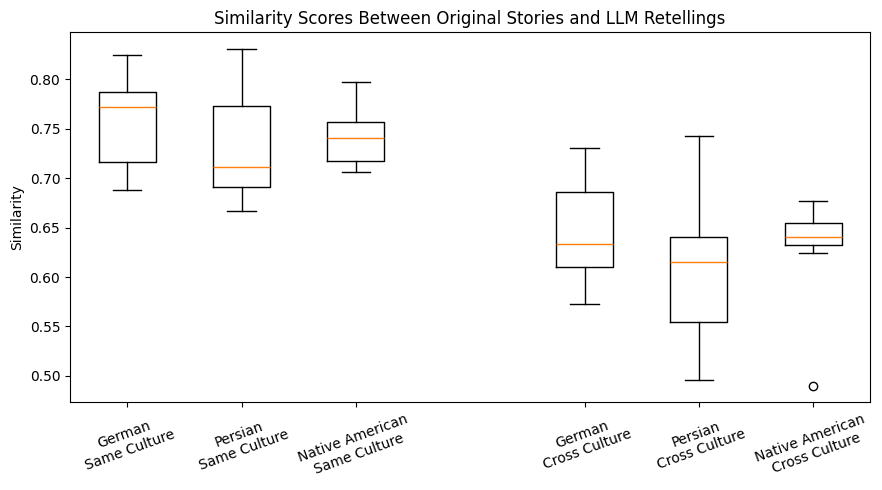

Saved figure to: report\human_llm_similarity_distribution.png


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# Paths
# =========================
META_PATH = Path("data/metadata.csv")
HUMAN_ROOT = Path("outputs/human_graphs")
SAME_ROOT = Path("outputs/llm_graphs/same_culture")
CROSS_ROOT = Path("outputs/llm_graphs/cross_culture")

REPORT_DIR = Path("report")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PAIRWISE_OUT = REPORT_DIR / "human_llm_similarity_scores.csv"
TABLE_OUT = REPORT_DIR / "human_llm_similarity_table.csv"
TABLE_LATEX_OUT = REPORT_DIR / "human_llm_similarity_table.tex"
FIG_OUT = REPORT_DIR / "human_llm_similarity_distribution.png"

# =========================
# Config
# =========================
MODEL_NAME = "all-MiniLM-L6-v2"

# Change this if you only want one condition:
# OPTIONS: "same_culture", "cross_culture", "both"
CONDITION_MODE = "both"

# =========================
# Helpers
# =========================
def normalize_culture_name(c: str) -> str:
    return str(c).strip().lower().replace("_", " ")

def pretty_culture_name(c: str) -> str:
    c = normalize_culture_name(c)
    if c == "native american":
        return "Native American"
    return c.title()

def load_event_labels(events_path: Path):
    if not events_path.exists():
        return []
    data = json.loads(events_path.read_text(encoding="utf-8"))
    return [x["label"] for x in data if "label" in x and str(x["label"]).strip()]

def story_similarity(labels_a, labels_b, model):
    """
    Symmetric embedding-based similarity between two stories:
    - embed event labels
    - compute cosine similarity matrix
    - average best-match similarity in both directions
    """
    if not labels_a or not labels_b:
        return np.nan

    emb_a = model.encode(labels_a, normalize_embeddings=True)
    emb_b = model.encode(labels_b, normalize_embeddings=True)

    sim = cosine_similarity(emb_a, emb_b)

    a_to_b = sim.max(axis=1).mean()
    b_to_a = sim.max(axis=0).mean()

    return float((a_to_b + b_to_a) / 2.0)

# =========================
# Load metadata
# =========================
meta = pd.read_csv(META_PATH)
required_cols = {"story_id", "culture"}
missing = required_cols - set(meta.columns)
if missing:
    raise ValueError(f"metadata.csv is missing columns: {missing}")

meta["culture"] = meta["culture"].apply(normalize_culture_name)

# =========================
# Build comparisons
# =========================
model = SentenceTransformer(MODEL_NAME)

rows = []

for _, row in meta.iterrows():
    story_id = str(row["story_id"])
    culture = normalize_culture_name(row["culture"])

    human_events_path = HUMAN_ROOT / story_id / "events.json"
    human_labels = load_event_labels(human_events_path)

    if not human_labels:
        continue

    if CONDITION_MODE in ("same_culture", "both"):
        same_events_path = SAME_ROOT / story_id / "events.json"
        same_labels = load_event_labels(same_events_path)

        if same_labels:
            sim_same = story_similarity(human_labels, same_labels, model)
            rows.append({
                "story_id": story_id,
                "culture": pretty_culture_name(culture),
                "condition": "Same Culture",
                "similarity": sim_same,
            })

    if CONDITION_MODE in ("cross_culture", "both"):
        cross_events_path = CROSS_ROOT / story_id / "events.json"
        cross_labels = load_event_labels(cross_events_path)

        if cross_labels:
            sim_cross = story_similarity(human_labels, cross_labels, model)
            rows.append({
                "story_id": story_id,
                "culture": pretty_culture_name(culture),
                "condition": "Cross Culture",
                "similarity": sim_cross,
            })

scores_df = pd.DataFrame(rows)
scores_df.to_csv(PAIRWISE_OUT, index=False)

print(f"Saved pairwise human–LLM scores to: {PAIRWISE_OUT}")

# =========================
# Summary table
# =========================
table_df = (
    scores_df.groupby(["culture", "condition"], as_index=False)["similarity"]
    .mean()
    .rename(columns={"similarity": "Human–LLM Similarity"})
    .sort_values(["condition", "culture"])
)

table_df["Human–LLM Similarity"] = table_df["Human–LLM Similarity"].round(4)
table_df.to_csv(TABLE_OUT, index=False)

latex_table = table_df.to_latex(index=False, float_format="%.4f")
TABLE_LATEX_OUT.write_text(latex_table, encoding="utf-8")

print(f"Saved summary table to: {TABLE_OUT}")
print(f"Saved LaTeX table to: {TABLE_LATEX_OUT}")
print("\nHuman–LLM similarity summary:\n")
print(table_df.to_string(index=False))

# =========================
# Figure
# =========================
plt.figure(figsize=(9, 5))

# boxplot-like grouped scatter with means
conditions = scores_df["condition"].unique()
cultures = ["German", "Persian", "Native American"]

positions = []
labels = []
x = 1

for cond in conditions:
    for cult in cultures:
        subset = scores_df[(scores_df["condition"] == cond) & (scores_df["culture"] == cult)]["similarity"].dropna()
        if len(subset) == 0:
            continue

        plt.boxplot(subset, positions=[x], widths=0.5)
        positions.append(x)
        labels.append(f"{cult}\n{cond}")
        x += 1

    x += 1  # extra gap between conditions

plt.xticks(positions, labels, rotation=20)
plt.ylabel("Similarity")
plt.title("Similarity Scores Between Original Stories and LLM Retellings")
plt.tight_layout()
plt.savefig(FIG_OUT, dpi=300)
plt.show()

print(f"Saved figure to: {FIG_OUT}")